In [180]:
import pandas as pd
import math
from ta.momentum import KAMAIndicator
from ta.trend import SMAIndicator
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

pd.options.mode.chained_assignment = None

import bb_ama_f

In [119]:
ticker='Eu'

parameters = pd.read_excel('data/parameters.xlsx')
parameters = parameters[parameters['ticker']==ticker]
parameters.head()

,ticker,num,ama_fast,ama_slow,ama_int,ma_period,ma_incline,ma_incline_int
3,Eu,1,1,81,78,2,0.404,18
4,Eu,2,2,18,66,10,0.444,13
5,Eu,3,3,10,76,10,0.347,7


In [198]:
data = pd.DataFrame()
quality = pd.DataFrame()

for i in range (1,4):
    ama_fast = int(parameters[parameters['num']==i]['ama_fast'])
    ama_slow = int(parameters[parameters['num']==i]['ama_slow'])
    ama_int = int(parameters[parameters['num']==i]['ama_int'])
    ma_period = int(parameters[parameters['num']==i]['ma_period'])
    ma_incline = float(parameters[parameters['num']==i]['ma_incline'])
    ma_incline_int = int(parameters[parameters['num']==i]['ma_incline_int'])
    result = bb_ama_f.algorithm_calc(ticker, ama_fast, ama_slow, ama_int,\
        ma_period, ma_incline, ma_incline_int, 1, 1, 'filtered', True)
    result['value'] = round(-result['yr rate']*result['correlation']/result['dd mean'], 4)
    result['num'] = 'v'+str(i)
    df = bb_ama_f.algorithm_calc(ticker, ama_fast, ama_slow, ama_int,\
        ma_period, ma_incline, ma_incline_int, 1, 1, 'filtered', False)
    df['num'] = 'v'+str(i)
    data = pd.concat([data,\
        df[['ticker', 'num', 'date', 'time', 'portfolio']]], axis=0, ignore_index=True)
    quality = pd.concat([quality, pd.DataFrame(result, index=[0])], axis=0, ignore_index=True)
quality

,yr rate,dd mean,dd max,correlation,deals,records,flat ratio,value,num
0,0.213739,-0.036868,-0.444301,0.262088,5304,45155,0.446152,1.5194,v1
1,0.168538,-0.032995,-0.567823,0.234827,2811,45155,0.601462,1.1995,v2
2,0.146906,-0.034872,-0.561383,0.276252,2874,45155,0.694962,1.1638,v3


In [199]:
data['num'] = data['num'].astype('category')

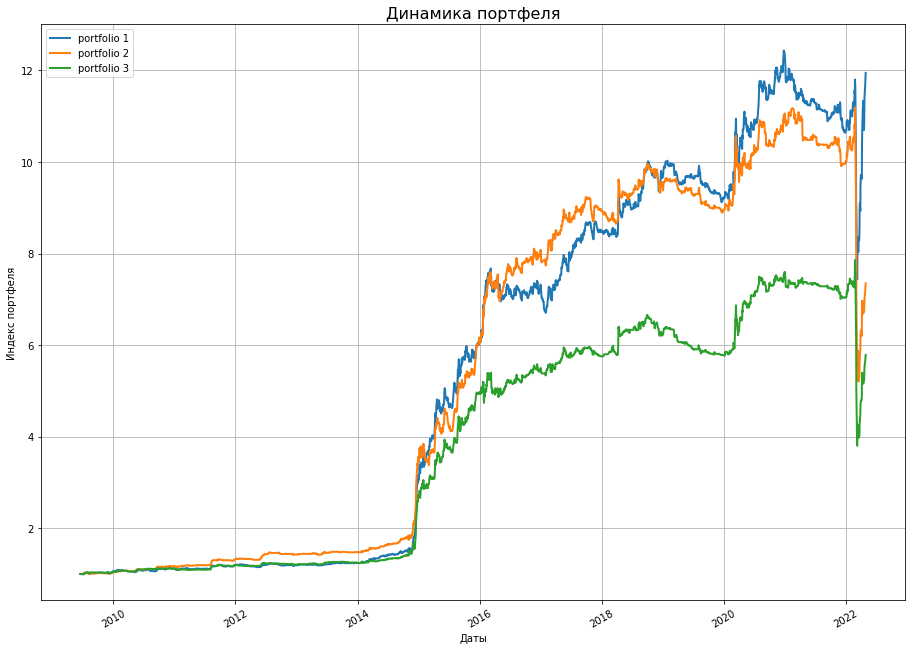

In [201]:
pf1 = data[data['num']=='v1'].groupby('date')['portfolio'].mean()
pf2 = data[data['num']=='v2'].groupby('date')['portfolio'].mean()
pf3 = data[data['num']=='v3'].groupby('date')['portfolio'].mean()

#визуализация графиков
fig = plt.figure(figsize=(12, 8))
axes = fig.add_axes([0, 0, 1, 1])
axes.plot(pf1, label='portfolio 1', lw=2)
axes.plot(pf2, label='portfolio 2', lw=2)
axes.plot(pf3, label='portfolio 3', lw=2)

#установка параметров отображения
axes.set_title('Динамика портфеля', fontsize=16)
axes.set_xlabel('Даты')
axes.set_ylabel('Индекс портфеля')
axes.xaxis.set_tick_params(rotation=30)
axes.grid()
axes.legend();

In [202]:
period = 14*21*12 #столько часов в квартале

data1 = data[data['num']=='v1']
data2 = data[data['num']=='v2']
data3 = data[data['num']=='v3']

data1['m_y'] = data1['portfolio'].diff(period)/data1['portfolio'].shift(period)*100
data2['m_y'] = data2['portfolio'].diff(period)/data2['portfolio'].shift(period)*100
data3['m_y'] = data3['portfolio'].diff(period)/data3['portfolio'].shift(period)*100

data = pd.concat([data1, data2, data3], axis=0, ignore_index=True)
data

,ticker,num,date,time,portfolio,m_y
0,SPFB.Eu,v1,2009-06-16,11:00:00,1.000000,NaN
1,SPFB.Eu,v1,2009-06-16,12:00:00,1.000000,NaN
2,SPFB.Eu,v1,2009-06-16,13:00:00,1.000000,NaN
3,SPFB.Eu,v1,2009-06-16,14:00:00,1.000000,NaN
4,SPFB.Eu,v1,2009-06-16,15:00:00,1.000000,NaN
...,...,...,...,...,...,...
135460,SPFB.Eu,v3,2022-04-29,15:00:00,5.832172,-21.570734
135461,SPFB.Eu,v3,2022-04-29,16:00:00,5.782200,-22.242742
135462,SPFB.Eu,v3,2022-04-29,17:00:00,5.777612,-22.304440
135463,SPFB.Eu,v3,2022-04-29,18:00:00,5.780774,-22.261918


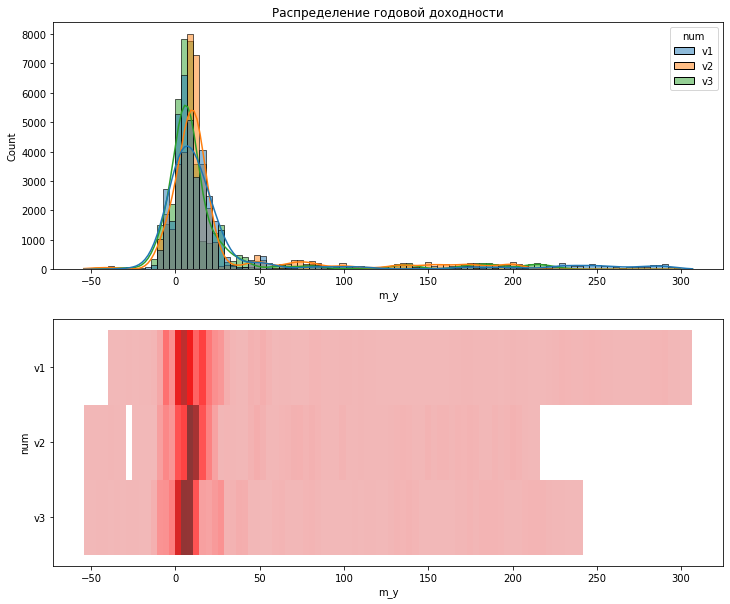

In [207]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
sns.histplot(
    data=data,
    x='m_y',
    bins=100,
    kde=True,
    hue='num',
    ax=axes[0],
)
axes[0].set_title('Распределение годовой доходности', fontsize=12)
sns.histplot(
    data=data,
    x='m_y',
    y='num',
    bins=100,
    color='red',
    ax=axes[1]
);

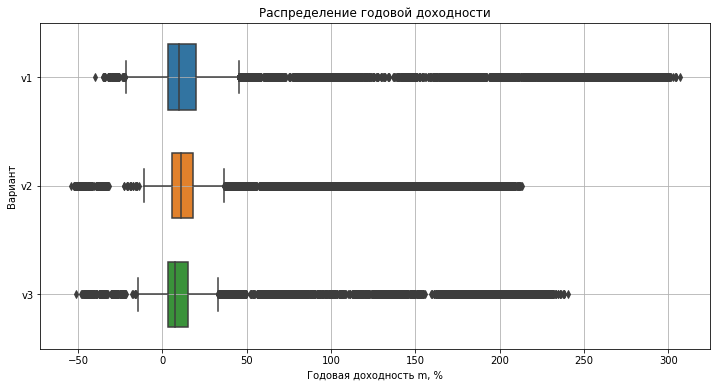

In [206]:
fig = plt.figure(figsize=(12, 6))
boxplot = sns.boxplot(
    data=data,
    x='m_y',
    y='num',
    orient='h',
    width=0.6
)

boxplot.set_title('Распределение годовой доходности');
boxplot.set_xlabel('Годовая доходность m, %');
boxplot.set_ylabel('Вариант');
boxplot.grid();

In [72]:
result_list = []
for i in range(1,5):
    for j in range(10, 101, 5):
        for k in range (10, 201, 5):
            quality = bb_ama_f.algorithm_calc(ticker, i, j, k,\
            ma_period, ma_incline, ma_incline_int, 1, 1, 'unfiltered', True)
            q_value = -quality['yr rate']*quality['correlation']/quality['dd mean']
            # создаём кортеж
            item = (i, j, k, q_value)
            result_list.append(item)
# создаём вспомогательную таблицу
quality_df = pd.DataFrame(
    result_list,
    columns=['ama_fast', 'ama_slow', 'ama_int', 'quality']
)

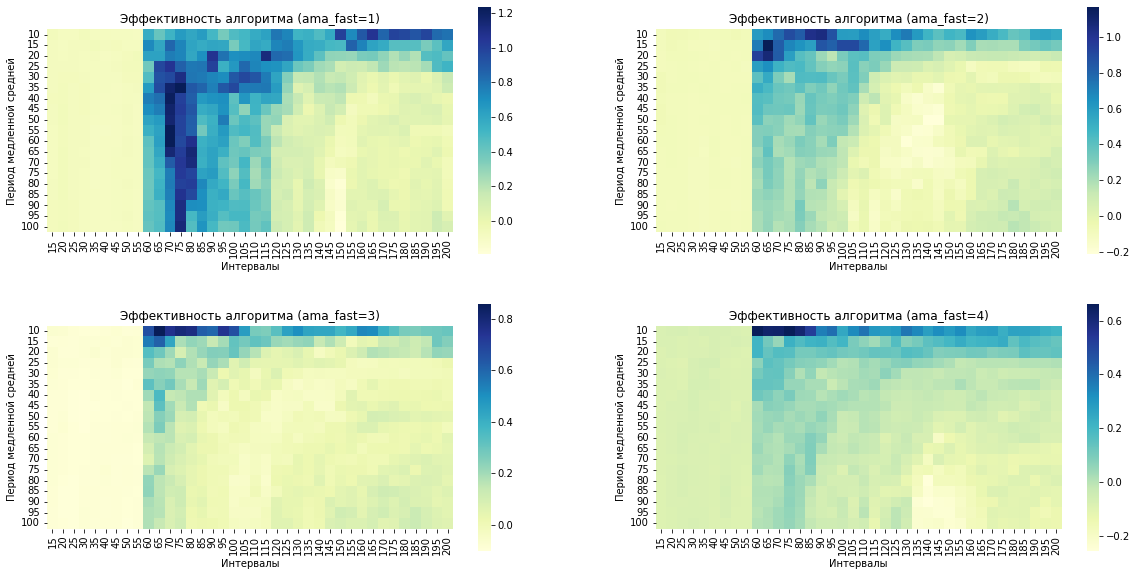

In [117]:
#строим сводную таблицу
pivot1 = quality_df[quality_df['ama_fast']==1].pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot2 = quality_df[quality_df['ama_fast']==2].pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot3 = quality_df[quality_df['ama_fast']==3].pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot4 = quality_df[quality_df['ama_fast']==4].pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

heatmap1 = sns.heatmap(data=pivot1, cmap='YlGnBu', annot=False, square=True, ax=axes[0,0])
heatmap1.set_title('Эффективность алгоритма (ama_fast=1)');
heatmap1.set_xlabel('Интервалы');
heatmap1.set_ylabel('Период медленной средней');

heatmap2 = sns.heatmap(data=pivot2, cmap='YlGnBu', annot=False, square=True, ax=axes[0,1])
heatmap2.set_title('Эффективность алгоритма (ama_fast=2)');
heatmap2.set_xlabel('Интервалы');
heatmap2.set_ylabel('Период медленной средней');

heatmap3 = sns.heatmap(data=pivot3, cmap='YlGnBu', annot=False, square=True, ax=axes[1,0])
heatmap3.set_title('Эффективность алгоритма (ama_fast=3)');
heatmap3.set_xlabel('Интервалы');
heatmap3.set_ylabel('Период медленной средней');

heatmap4 = sns.heatmap(data=pivot4, cmap='YlGnBu', annot=False, square=True, ax=axes[1,1])
heatmap4.set_title('Эффективность алгоритма (ama_fast=4)');
heatmap4.set_xlabel('Интервалы');
heatmap4.set_ylabel('Период медленной средней');

In [118]:
print(quality_df[quality_df['ama_fast']==1]['quality'].max())
print(quality_df[quality_df['ama_fast']==2]['quality'].max())
print(quality_df[quality_df['ama_fast']==3]['quality'].max())
print(quality_df[quality_df['ama_fast']==4]['quality'].max())

1.2328398692355902
1.1657474775575525
0.8586189243187385
0.6628958692774118
